Stripe only uplink example
----------------------------
This notebook shows how to receive a CP-OFDM signal on the stripe and propagate it towards the central unit. All the radio units receive the signal and propagate it one by one where the furthest unit starts propagating first.

In [1]:
import yaml
import numpy as np
import matplotlib.pyplot as plt

from plotter import plotter
from utils import calculate_psd_per_symbol
from sub_THz_stripe.radiostripe.radiostripe import RadioStripe
from sub_THz_stripe.central_unit.central_unit import CentralUnit
from sub_THz_stripe.radio_unit.radio_unit import RadioUnit
from wireless_channel.subTHz_channel import Channel
from wireless_channel.waveforms import Waveform

In [2]:
# Read out the config file.
config_file = "examples/stripe_ul/config.yml"
with open(config_file, "r", encoding="utf8") as file:
    config = yaml.safe_load(file)

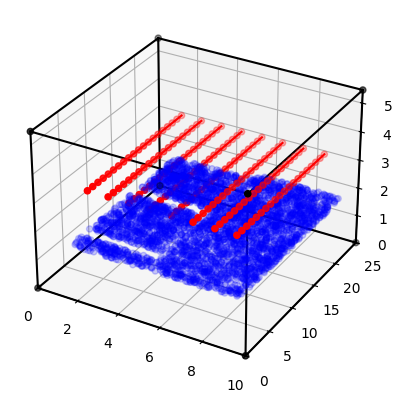

In [3]:
# Plot the room with the strip in it.
plotter.plot_room(config)

In [4]:
# Construct the waveform class based on the loaded configuration.
waveform_config = config["waveform_config"]
freq_band_config = config["sub_thz"]
wf = Waveform.from_config(waveform_config, freq_band_config)

ue_pos = None
for ue in config["ue_positions"]:
    if ue["x"] == 2.0 and ue["y"] == 21.5 and ue["z"] == 1.5:
        ue_pos = ue
        break

In [5]:

# Build all the RadioStripe objects based on the configuration.
stripes: list[RadioStripe] = []
component_config = config["component_config"]
stripe_cfg = config["radio_stripes"][0]
for stripe_cfg in config["radio_stripes"]:
    stripes.append(RadioStripe.from_config_locations(stripe_cfg, component_config, wf))

for stripe in stripes:
    for ru in stripe.radio_units:
        ru.antenna_amp.set_noise_var(273.15 + 25, config["sub_thz"]["bw"], 10)
        ru.boost_amp.set_noise_var(273.15 + 25, config["sub_thz"]["bw"], 10)

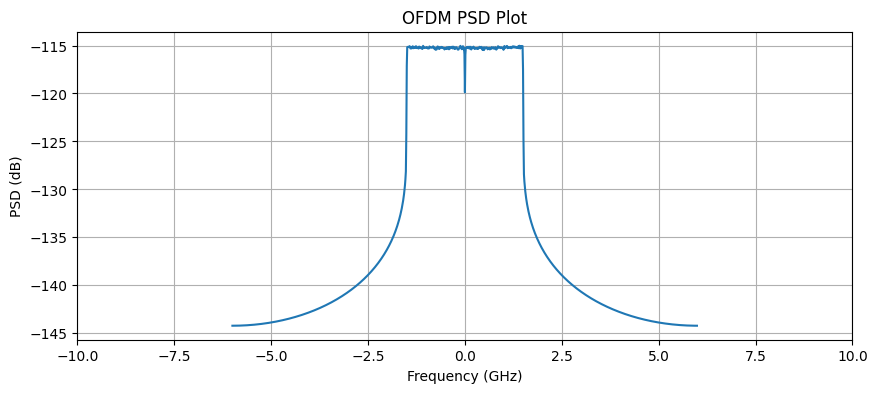

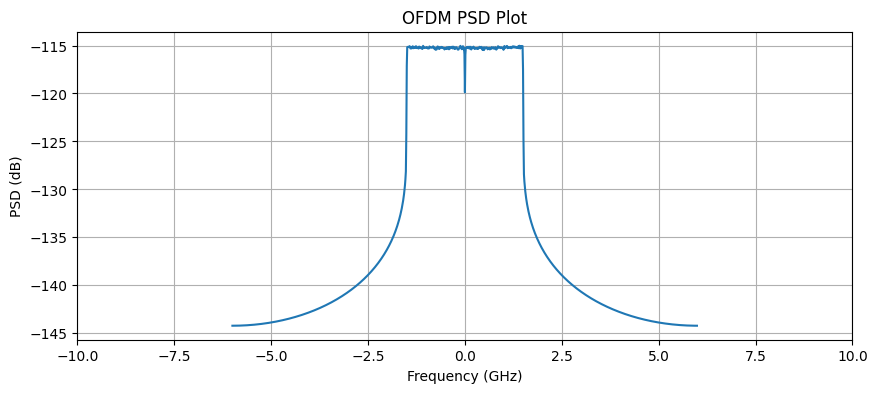

In [6]:
# Generate an CP-OFDM waveform in the time domain.
bits = wf.generate_bits()
qam = wf.qam_modulate()
ofdm_time = wf.ofdm_modulate()  # shape: nr_ofdm_symb x (fftsize + cp length)
wf.plot_psd()

In [7]:
cu = CentralUnit()  # todo are these configs loadable?
ofdm_time_after_cu = cu.run(ofdm_time)  # shape: nr_ofdm_symbols x (fft_size + cp length)

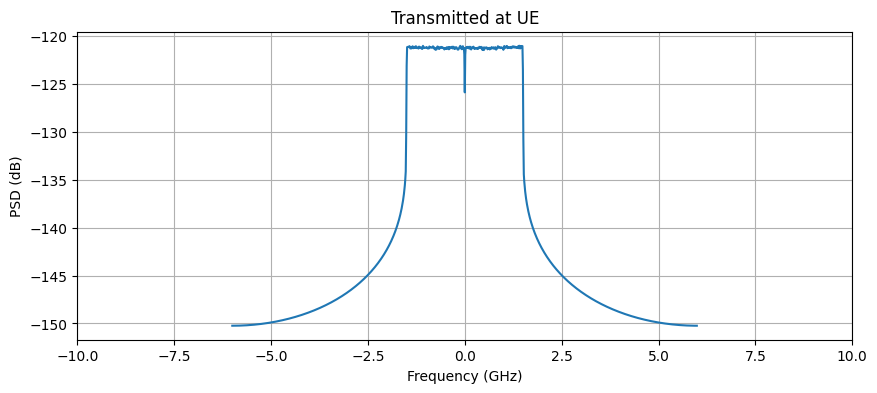

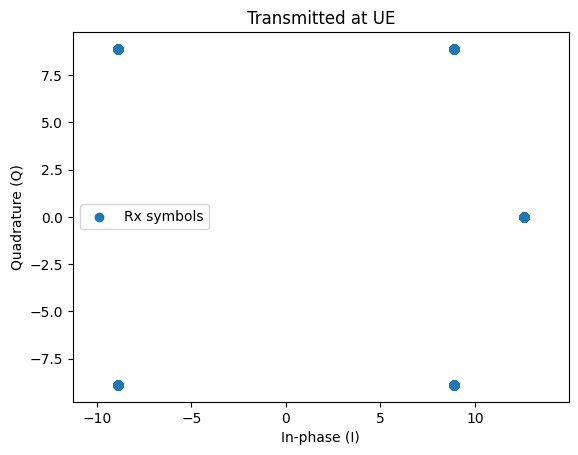

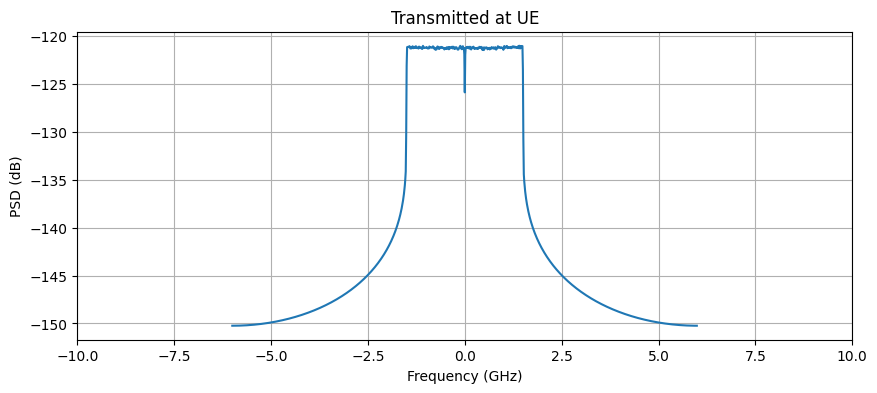

In [8]:
ue = RadioUnit(ue_pos["x"], ue_pos["y"], ue_pos["z"], wf)
shifts = [0, 0, 0, 0]
iq_data_tx, imdata = ue.transmit(ofdm_time_after_cu, shifts)
# Make an IQ-plot and PSD-plot of the data transmitted at the UE (one antenna).
wf.plot_iq_time(iq_data_tx[0], title="Transmitted at UE")
wf.plot_psd(iq_data_tx[0], title="Transmitted at UE")

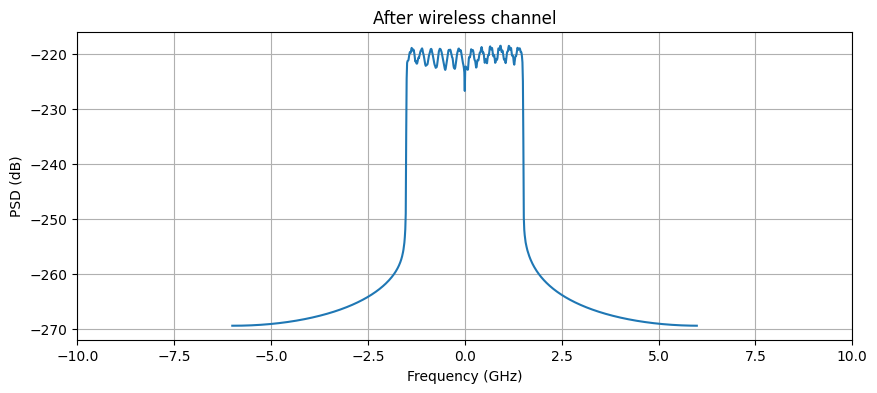

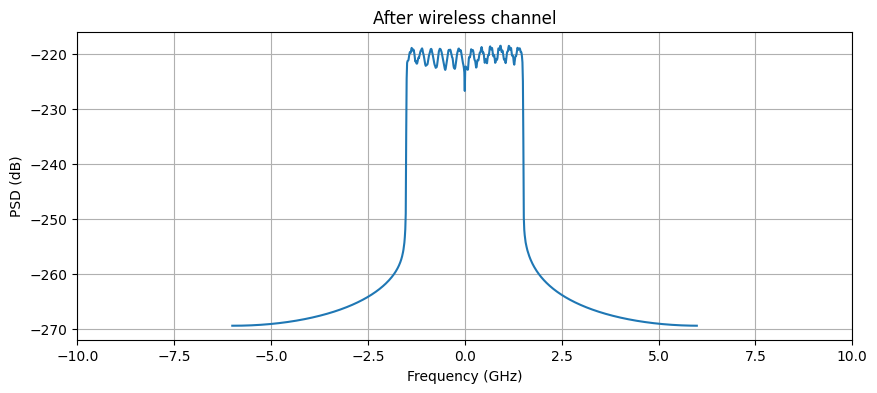

In [9]:
channel = Channel.from_sionna(ue_pos, "office1_measured")
iq_data_rus = channel.transmit_ul(iq_data_tx, wf)
wf.plot_psd(iq_data_rus[0][0][0], title="After wireless channel")

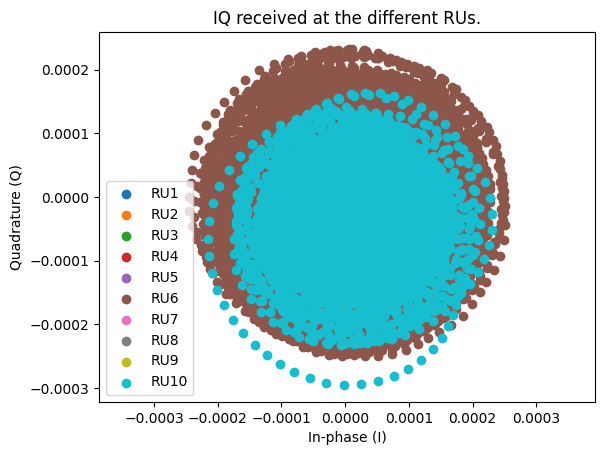

In [10]:
# Plot the received IQ-data for several RUs of the first stripe.
ru_ofdm_freqs = []
for i, ru_data in enumerate(iq_data_rus[0][0:10]):
    ru_ofdm_freqs.append(wf.ofdm_time_to_freq(ru_data[0])[0])

labels = [f"RU{i+1}" for i in range(config["stripe_config"]["N_RUs"])]
fig = plotter.plot_constellation(np.array(ru_ofdm_freqs), labels=labels, title="IQ received at the different RUs.")

In [11]:
print(f"UE position: x{ue_pos["x"]} y{ue_pos["y"]} z{ue_pos["z"]}")
ru_shift = [0, 0, 0, 0]
stripe_data = []
for stripe_idx, (stripe, data) in enumerate(zip(stripes, iq_data_rus)):
    stripe.active_unit = 19
    y, imdata = stripe.receive(data, ru_shift, False)

    stripe_data.append(y)

UE position: x2.0 y21.5 z1.5


NMSE: -31.931083341204793
BER: 0.0


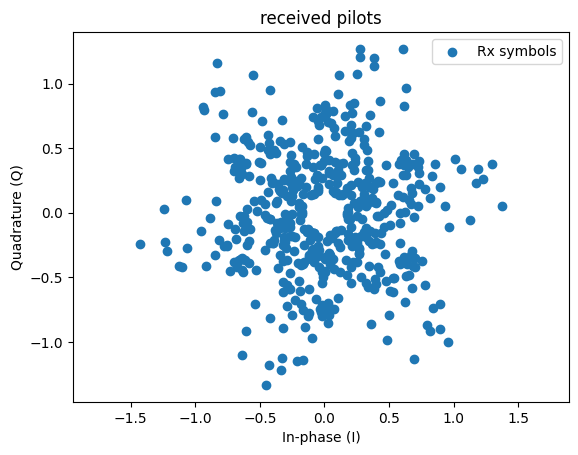

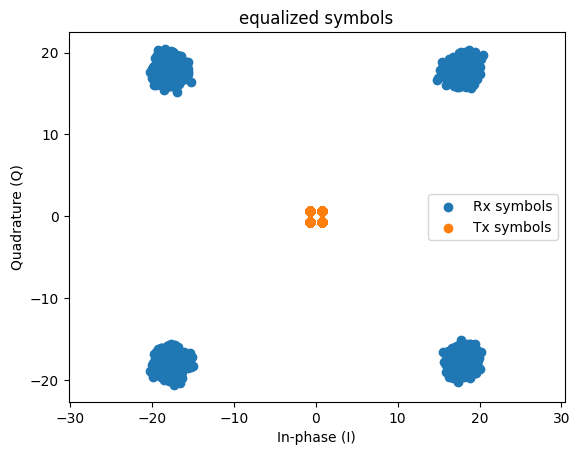

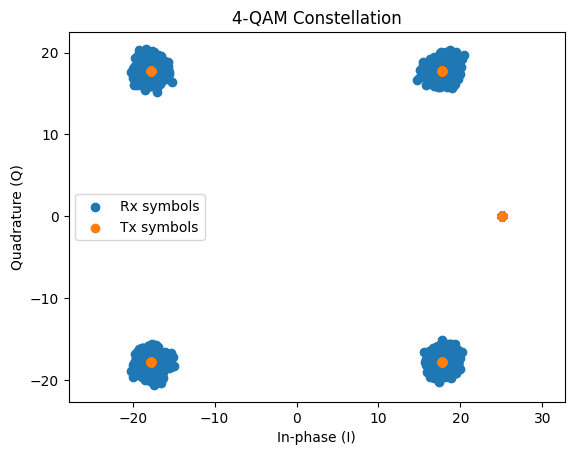

In [12]:
y_combined_freq = wf.ofdm_time_to_freq(stripe_data[0])
x_combined_freq = wf.ofdm_time_to_freq(ofdm_time)
xsubc = wf.extract_subcarriers(x_combined_freq)

# sanity check
rx_subc = wf.extract_subcarriers(y_combined_freq)
# look at a few carriers around pilots and data
wf.plot_constellation(rx_subc[0, wf.pilot_indices], title="received pilots")

# channel estimation
subc = wf.extract_subcarriers(y_combined_freq)
H_est = wf.channel_estimate_ls(subc)

# equalization
eq_subc = wf.equalize_one_tap(subc, H_est)

nmse = np.sum(np.abs(eq_subc - xsubc) ** 2) / np.sum(np.abs(xsubc) ** 2)

# Demap data carriers and rebuild stream
data_symbols = wf.demap_data_from_grid(eq_subc).flatten()  # these are the received QAM symbols

y_qam = data_symbols

# quick sanity
assert y_qam.shape[0] == qam.shape[0], f"Lengths differ: rx {y_qam.shape[0]} tx {qam.shape[0]}"

wf.plot_constellation(y_qam, symbols_tx=qam, title="equalized symbols")
wf.plot_constellation(eq_subc, symbols_tx=xsubc)

y_bits = wf.qam_to_bits(y_qam)

ber = wf.compute_ber(bits, y_bits)
print(f"NMSE: {10 * np.log10(nmse)}")
print(f"BER: {ber}")